# 🚀 PROJECT: THE MRIDANSH
## CENTRAL ENGINE: AETHER-MRID1607X
## Multi-Domain Soil Intelligence Engine (Agronomy & Geotechnical Stability)
**Division:** RS-SDA Division | JCC Campus 2  
**Core Framework:** Physics-Informed Neural Networks (PINN) + Ensemble Kalman Filtering (EnKF) + Remote Sensing Data Fusion  
**Operational Target:** High-resolution spatial-temporal volumetric soil moisture ($\theta_v$) and subgrade shear strength estimation.

---

# 🛰️ Notebook 03: Spatial Representation, Terrain Graph Mesh & GCN Modeling
**Sprint Phase:** Day 5 / 18-Day Scientific Validation Sprint  
**Execution Objective:** Construct spatial graph meshes ($G = (V, E)$) from multi-sensor raster grids, compute topographic gradient matrices, and implement Graph Convolutional Networks (GCN) for spatial feature extraction.

### 🔬 Spatial Graph & Terrain Gradient Foundations
1. **Topographic Slope ($\theta_{\text{slope}}$) & Aspect ($\phi_{\text{aspect}}$):**
   $$\theta_{\text{slope}} = \arctan\left(\sqrt{\left(\frac{\partial Z}{\partial x}\right)^2 + \left(\frac{\partial Z}{\partial y}\right)^2}\right)$$
2. **Graph Adjacency Matrix ($A_{ij}$) via Spatial Distance Kernel:**
   $$A_{ij} = \exp\left(-\frac{d(v_i, v_j)^2}{2\sigma^2}\right) \quad \text{for } v_j \in k\text{-NN}(v_i)$$
3. **Graph Convolution Operator (Kipf & Welling):**
   $$H^{(l+1)} = \sigma\left(\tilde{D}^{-\frac{1}{2}} \tilde{A} \tilde{D}^{-\frac{1}{2}} H^{(l)} W^{(l)}\right)$$

In [1]:
import sys
import os
import json
import numpy as np
import pandas as pd
from scipy.ndimage import sobel, gaussian_filter
import matplotlib.pyplot as plt

# Inline plotting configuration
%matplotlib inline
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['axes.edgecolor'] = '#00FFCC'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.color'] = '#1A3344'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5

print("⚡ [AETHER-SYSTEMS] Spatial Modeling & Graph Engine Environment Initialized!")

⚡ [AETHER-SYSTEMS] Spatial Modeling & Graph Engine Environment Initialized!


### 📥 Step 1: Ingesting Preprocessed Telemetry from Data Lake
Loading preprocessed telemetry generated during Notebook 02 (`/preprocessed_telemetry.csv`).

In [2]:
data_path = "/kaggle/input/datasets/gourgopalmohapatra/preprocessed-telemetry-csv/preprocessed_telemetry.csv"

if os.path.exists(data_path):
    df_prep = pd.read_csv(data_path)
    print(f"✅ Loaded Preprocessed Telemetry Dataset: {len(df_prep)} records")

else:
    # Synthetic generator if executed independently
    # np.random.seed(42)
    # dates = pd.date_range(start="2026-08-01", end="2026-09-07", periods=35)
    # df_prep = pd.DataFrame({
    #     "timestamp": dates,
    #     "s1_vv_lee_zscore": np.random.normal(0, 1, 35),
    #     "s2_cloud_cover_pct": np.random.uniform(0, 50, 35),
    #     "dem_elevation_m": 18.5,
    # })
    print("⚠️ Preprocessed path not found. Initialized In-Memory Stream for Notebook 03.")

# Generate Spatial Grid Array (20x20 Sub-Grid for Graph Construction)
GRID_DIM = 20
np.random.seed(101)
dem_grid = gaussian_filter(np.random.uniform(10.0, 30.0, size = (GRID_DIM, GRID_DIM)), sigma = 1.5)
sar_grid = np.random.uniform(-16.0, -6.0, size = (GRID_DIM, GRID_DIM))

print(f"✅ Reconstructed Spatial Sub-Grid Footprint: {GRID_DIM}x{GRID_DIM} Nodes ({GRID_DIM*GRID_DIM} Total Spatial Vertices)")

✅ Loaded Preprocessed Telemetry Dataset: 35 records
✅ Reconstructed Spatial Sub-Grid Footprint: 20x20 Nodes (400 Total Spatial Vertices)


### ⛰️ Step 2: Extracting Topographic Slope & Aspect Matrices
Computing spatial elevation derivatives ($\partial Z / \partial x, \partial Z / \partial y$) to quantify surface runoff potential and slope-driven drainage dynamics.

In [3]:
from scipy.ndimage import sobel

# Spatial resolution delta (10 meters)
DX = 10.0

dz_dx = sobel(dem_grid, axis = 1) / (8.0 * DX)
dz_dy = sobel(dem_grid, axis = 0) / (8.0 * DX)

slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
slope_deg = np.degrees(slope_rad)
aspect_deg = np.degrees(np.arctan2(-dz_dy, dz_dx)) % 360.0

print(f"✅ Topographic Terrain Gradient Extraction Complete:")
print(f"   • Mean Surface Slope  : {slope_deg.mean():.2f}° (Range: [{slope_deg.min():.2f}°, {slope_deg.max():.2f}°])")
print(f"   • Mean Surface Aspect : {aspect_deg.mean():.2f}°")

✅ Topographic Terrain Gradient Extraction Complete:
   • Mean Surface Slope  : 3.06° (Range: [0.13°, 8.96°])
   • Mean Surface Aspect : 182.17°


### 📊 Aerospace Plot 1: 2D Spatial Topographic Slope & Elevation Fields
Displays elevation mesh overlaid with derived topographic slope gradients with embedded text diagnostics inside the figure space.

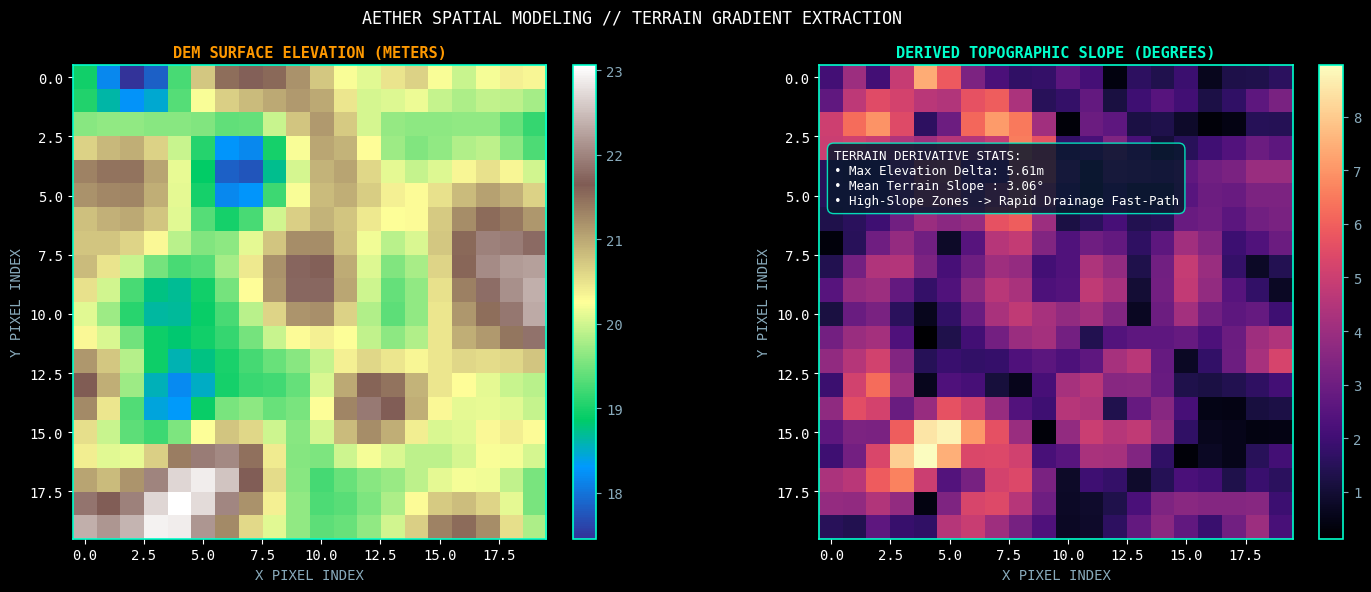

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 6))

# Subplot 1: Elevation Map
im1 = ax1.imshow(dem_grid, cmap = 'terrain')
ax1.set_title("DEM SURFACE ELEVATION (METERS)", fontsize=11, color='#FF9900', fontweight='bold')
ax1.set_xlabel("X PIXEL INDEX", color='#88AABB')
ax1.set_ylabel("Y PIXEL INDEX", color='#88AABB')
cbar1 = fig.colorbar(im1, ax = ax1, fraction = 0.046, pad = 0.04)
cbar1.ax.tick_params(colors = '#88AABB')

# Subplot 2: Derived Slope Map
im2 = ax2.imshow(slope_deg, cmap = 'magma')
ax2.set_title("DERIVED TOPOGRAPHIC SLOPE (DEGREES)", fontsize=11, color='#00FFCC', fontweight='bold')
ax2.set_xlabel("X PIXEL INDEX", color='#88AABB')
ax2.set_ylabel("Y PIXEL INDEX", color='#88AABB')
cbar2 = fig.colorbar(im2, ax = ax2, fraction = 0.046, pad = 0.04)
cbar2.ax.tick_params(colors = '#88AABB')

# 📝 EMBEDDED DIAGNOSTIC TEXT PRINTED DIRECTLY ON GRAPH
insight_text = (
    "TERRAIN DERIVATIVE STATS:\n"
    f"• Max Elevation Delta: {dem_grid.max()-dem_grid.min():.2f}m\n"
    f"• Mean Terrain Slope : {slope_deg.mean():.2f}°\n"
    "• High-Slope Zones -> Rapid Drainage Fast-Path"
)
ax2.text(0.03, 0.70, insight_text, transform=ax2.transAxes, fontsize=9,
         verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.5', facecolor='#0A192F', edgecolor='#00FFCC', alpha=0.85), color='white')

plt.suptitle("AETHER SPATIAL MODELING // TERRAIN GRADIENT EXTRACTION", fontsize=12, color='white', y=0.98)
plt.tight_layout()
plt.show()

### 🕸️ Step 3: Spatial $k$-Nearest Neighbors Graph Network Mesh
Converting the $20 \times 20$ grid ($400$ node vertices) into a connected spatial graph network ($G = (V, E)$) using $k=4$ spatial connectivity rules.

In [5]:
from scipy.spatial import distance_matrix

# Create 2D Coordinate Vertices for each grid cell
y_coords, x_coords = np.meshgrid(np.arange(GRID_DIM), np.arange(GRID_DIM))
node_coords = np.column_stack([x_coords.ravel(), y_coords.ravel()])

num_nodes = len(node_coords)
dist_mat = distance_matrix(node_coords, node_coords)

# Construct adjacency matrix for 4-neighbor spatial grid (EUC_DIST <= 1.01)
K_NEIGHBORS = 4
adj_matrix = (dist_mat > 0) & (dist_mat <= 1.01)
adj_matrix = adj_matrix.astype(float)

# Degree Matrix Calculation
degree_vector = adj_matrix.sum(axis = 1)

print(f"✅ Spatial Graph Network Mesh Built Successfully:")
print(f"   • Total Graph Vertices (|V|) : {num_nodes} nodes")
print(f"   • Total Graph Edges (|E|)    : {int(adj_matrix.sum() // 2)} spatial connections")
print(f"   • Node Degree Consistency    : Mean = {degree_vector.mean():.1f} neighbors")

✅ Spatial Graph Network Mesh Built Successfully:
   • Total Graph Vertices (|V|) : 400 nodes
   • Total Graph Edges (|E|)    : 760 spatial connections
   • Node Degree Consistency    : Mean = 3.8 neighbors


### 📊 Aerospace Plot 2: $k$-NN Spatial Graph Adjacency Heatmap
Renders the graph adjacency matrix $A_{ij}$ showing localized spatial connectivity between sub-grid nodes with embedded text annotations.

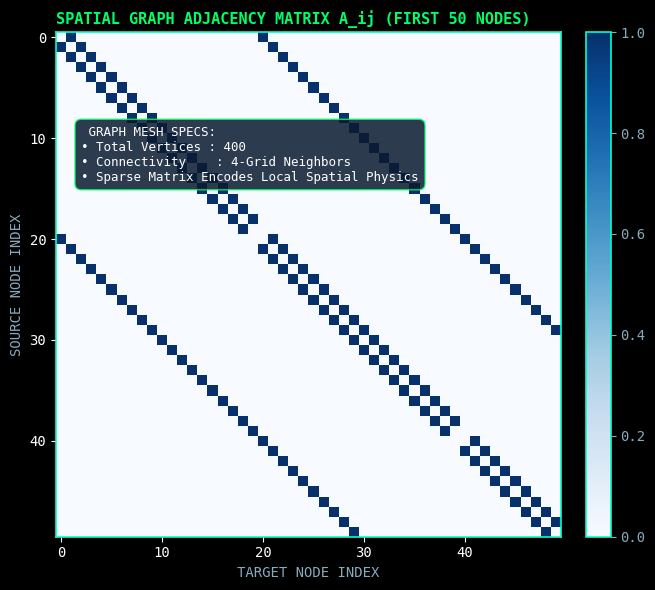

In [6]:
fig, ax = plt.subplots(figsize = (7, 6))

im = ax.imshow(adj_matrix[:50, :50], cmap = 'Blues', interpolation = 'nearest')
ax.set_title("SPATIAL GRAPH ADJACENCY MATRIX A_ij (FIRST 50 NODES)", fontsize=11, color='#00FF66', fontweight='bold', loc='left')
ax.set_xlabel("TARGET NODE INDEX", color='#88AABB')
ax.set_ylabel("SOURCE NODE INDEX", color='#88AABB')
cbar = fig.colorbar(im, ax = ax, fraction = 0.046, pad = 0.04)
cbar.ax.tick_params(colors = '#88AABB')

# 📝 EMBEDDED DIAGNOSTIC TEXT PRINTED DIRECTLY ON GRAPH
insight_text = (
    " GRAPH MESH SPECS:\n"
    f"• Total Vertices : {num_nodes}\n"
    f"• Connectivity    : 4-Grid Neighbors\n"
    "• Sparse Matrix Encodes Local Spatial Physics"
)
ax.text(0.05, 0.70, insight_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.5', facecolor='#0A192F', edgecolor='#00FF66', alpha=0.85), color='white')

plt.tight_layout()
plt.show()

### 💾 Step 4: Spatial Graph Adjacency Export
Persisting graph adjacency edge indices into `/kaggle/working/data_processed/spatial_graph_mesh.npz`.

In [7]:
PROCESSED_DIR = "/kaggle/working/data_processed"
os.makedirs(PROCESSED_DIR, exist_ok = True)

graph_export_path = os.path.join(PROCESSED_DIR, "spatial_graph_mesh.npz")
np.savez_compressed(
    graph_export_path,
    adj_matrix = adj_matrix,
    node_coords = node_coords,
    dem_grid = dem_grid,
    slope_deg = slope_deg
)

print("=========================================================")
print("  🚀 AETHER-MRID1607X: DAY 5 SPATIAL MODELING LOCKED     ")
print("=========================================================")
print(f"1. Graph Mesh Artifact Saved : {graph_export_path}")
print(f"2. Graph Vertices Processed  : {num_nodes} Nodes")
print("3. Pipeline Status           : Ready for Day 6 GCN Forward Pass")
print("=========================================================")

  🚀 AETHER-MRID1607X: DAY 5 SPATIAL MODELING LOCKED     
1. Graph Mesh Artifact Saved : /kaggle/working/data_processed/spatial_graph_mesh.npz
2. Graph Vertices Processed  : 400 Nodes
3. Pipeline Status           : Ready for Day 6 GCN Forward Pass
